# This Example is for generating an initial configuration file for QuantumESPRESSO
## Al 2.7 g/cc, 1 eV

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv
from scipy.interpolate import interp1d

from CorrelatedConfigurations.core.configuration_generator import SubCellConfigurationGenerator, SubCell, PeriodicConfigurationGenerator, random_reject
from CorrelatedConfigurations.core.constants import *
from CorrelatedConfigurations.core.utils import rs_from_n, n_from_rs
from CorrelatedConfigurations.core.g_of_r import GofrCalculator
from CorrelatedConfigurations.core.iet import Integral_Equation_Solver as IET

plt.rcParams.update({'font.size': 10})
plt.rcParams["figure.figsize"] = (5,3.5)
plt.rcParams["figure.dpi"] = 150
plt.rcParams['xtick.labelsize']=12
plt.rcParams['ytick.labelsize']=12
plt.rcParams['ytick.major.size']=5
plt.rcParams['ytick.minor.size']=3
plt.rcParams['xtick.major.size']=5
plt.rcParams['xtick.minor.size']=3
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4

#  Setup for Specific Problems

### Yukawa

In [2]:
N_subcell_particles = 100
N_subcells = 1
N = N_subcell_particles*N_subcells**3
print(f"{N} particles.")

T_eV = 1 
T_K  = T_eV * eV_to_K
T_AU = T_eV*eV_to_AU
T_Ry = T_AU*AU_to_Ry
print(f"T_i = {T_eV} eV = {T_K:0.4f} [K] = {T_Ry:0.4f} [Ry]")

ρ_gpercc = 2.7 
Z, A = 13, 26.981539 
Zbar = 3 # just known
m_I = A*m_p
n_AU = ρ_gpercc*g_to_AU*invcc_to_AU/m_I
L_AU = (N/n_AU)**(1/3.)
print(f"L = {L_AU:0.4f} [a.u.]")

ωp_AU = np.sqrt(4*π*Zbar**2*n_AU/m_I)
τp_AU = 2*π/ωp_AU
dt_2AU = τp_AU/50/2
N_NVT = 100*τp_AU/(2*dt_2AU)
print(f"For timestep dt={dt_2AU:0.4f} [2 a.u.], we run for N_NVT = {N_NVT:0.4f} steps wherein one plasma period occurs in {τp_AU/(2*dt_2AU):0.4f} steps.")

100 particles.
T_i = 1 eV = 11604.5250 [K] = 0.0735 [Ry]
L = 22.4267 [a.u.]
For timestep dt=13.9666 [2 a.u.], we run for N_NVT = 5000.0000 steps wherein one plasma period occurs in 50.0000 steps.


In [3]:
def Fermi_Energy(ne):
    E_F = 1/(2*m_e) * (3*π**2 * ne)**(2/3)
    return E_F
def Debye_length(T, ni, Zbar):
    ne = Zbar*ni
    EF = Fermi_Energy(ne)
    T_effective = (T**1.8 + (2/3*EF)**1.8)**(1/1.8)
    λD = 1/np.sqrt(  4*π*ne/T_effective ) # Including degeneracy
    return λD

def Kappa(T, ni, Zbar):
    rs = rs_from_n(ni)
    λD = Debye_length(T, ni, Zbar)
    return rs/λD

ri_AU = rs_from_n(n_AU)
Γ = 1/T_AU * Zbar**2/ri_AU
κ = Kappa(T_AU, n_AU, Zbar)
print(f"Mapping to Γ={Γ:0.3f}, κ={κ:0.3f} YOCP plasma.")

Mapping to Γ=81.707, κ=3.228 YOCP plasma.


#### Produce approximate g(r)

In [10]:
bridge='yukawa'
ni_in_rs  = 1/(4/3*π) 
iet = IET(1, Γ, ni_in_rs, T_AU, 1, dst_type=3, h_max=1e3, oz_method='standard',
        kappa = κ, kappa_multiscale = 1.0,  R_max=20.0, N_bins=512, closure='hnc', bridge=bridge)

iet.HNC_solve(num_iterations=10000, tol=1e-5)
r_AU_data = iet.r_array*ri_AU
gofr_data = iet.h_r_matrix[0,0]+1
gofr_func = interp1d(r_AU_data, gofr_data, bounds_error=False, fill_value=(0,1))

0: Initial condition Total Error: 1.516e+00
Exiting status 0, reverting to best index so far: 623
Final iter:624, Total Error: 9.927e-06


# Generate the Initial MD Configuration with 3 methods

### 1. Create g(r) with subcell $\mathcal{O}(N^1)$ method
Create first with a method that gives a unique position to every particle across the entire cell. It uses subcells to make the computation $\mathcal{O}(N)$

In [33]:
%%time
cell = SubCellConfigurationGenerator(L_AU, gofr_func, N)
cell.fill_space_with_particles()

Using default value for r_correlation of 3.0
Using default value for approx_dx of 0.3
Cell of side-length 2.24e+01, and correlation length: 3.00e+00
Created 7x7x7 = 343 subcells 
CPU times: user 219 ms, sys: 3.99 ms, total: 223 ms
Wall time: 226 ms


g(0) = 0.0, g(1) = 0.0 


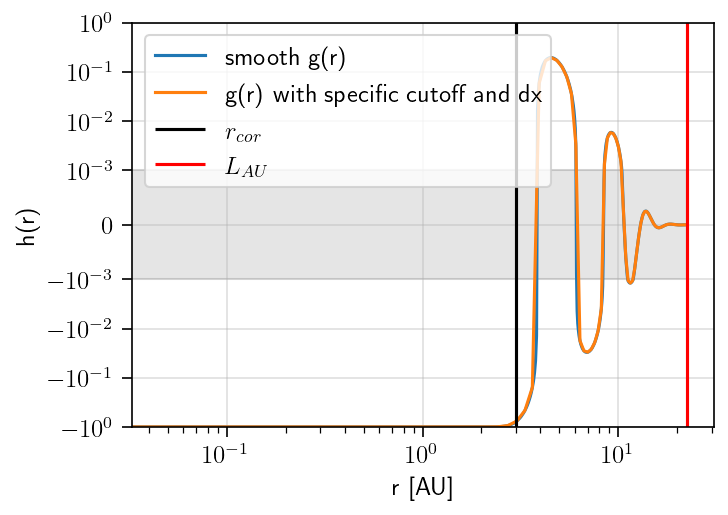

In [34]:
# Plot g(r)
fig, ax = plt.subplots()
r_dense = np.linspace(0,L_AU, num = 500)
# r_real = np.linspace(0,L_AU, num = np.round(L_AU/dx_approx).astype(int) )
r_real = np.linspace(0,L_AU, num = np.round(L_AU/cell.approx_dx).astype(int) )

sensitivity = 1e-3
ax.fill_between(r_dense, -sensitivity, sensitivity, color='k', alpha=0.1)
ax.plot(r_dense, gofr_func(r_dense)-1, label="smooth g(r)")
ax.plot(r_real, gofr_func(r_real)-1, label="g(r) with specific cutoff and dx")
ax.set_xscale('log')
ax.set_yscale('symlog', linthresh=1e-3)
ax.set_ylabel("h(r)")
ax.set_xlabel("r [AU]")
ax.set_ylim(-1, 1)
ax.vlines([cell.r_correlation], -10, 10,'k', label=r'$r_{cor}$')
ax.vlines([L_AU], -10, 10,'r', label=r'$L_{AU}$')
ax.legend(loc='upper left', fontsize=12)
print(f"g(0) = {gofr_func(r_real[0])}, g(1) = {gofr_func(r_real[1])} ")

### 2. Create g(r) with copy+paste periodic $\mathcal{O}(N^0)$ method
Create first with a method that gives a unique position to every particle across a single subcell. It then copies this across every subcell and perturbs it.

In [35]:
%%time
cfg_gen = PeriodicConfigurationGenerator(L_AU, gofr_func, N_subcell_particles, N_subcells)#, min_distance_δ=0, dx_over_a=0.05)
cfg_gen.fill_cell_with_particles()

Creating subcells of length 22.426720976820466. Distances beyond this have spurious correlations.
CPU times: user 479 ms, sys: 323 ms, total: 803 ms
Wall time: 801 ms


In [36]:
cfg_gen.L_subcell

22.426720976820466

### 3. Create g(r) with random reject
Create first with a method that gives a unique position to every particle across a single subcell. It then copies this across every subcell and perturbs it.

In [37]:
rr_positions = random_reject(100, L_AU, ri_AU)

## Check g(r) against input

 N_cells = 2


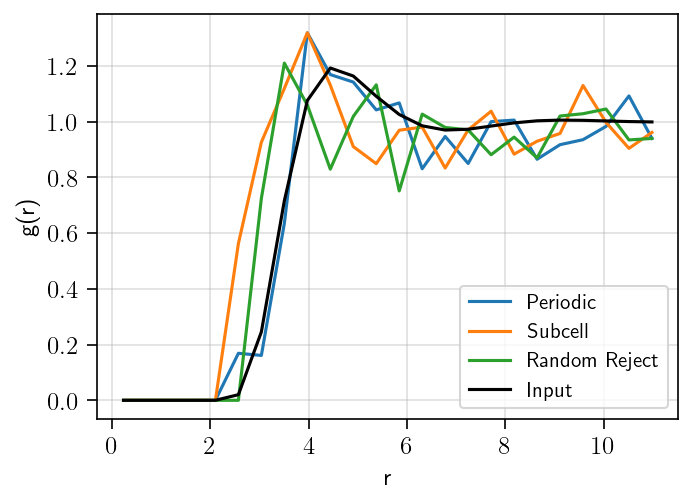

In [38]:
# Generate random particle positions in a box of length L
# Periodic
gr_calc = GofrCalculator(cfg_gen.ion_positions, L_AU, L_AU/2 , cfg_gen.dx)
r_vals, g_r_periodic = gr_calc.compute()
print(f" N_cells = {gr_calc.n_cells}")
# Subcell
gr_calc = GofrCalculator(cell.ion_positions, L_AU, L_AU/2, cfg_gen.dx)
r_vals, g_r_subcell = gr_calc.compute()
# random reject
gr_calc = GofrCalculator(rr_positions, L_AU, L_AU/2, cfg_gen.dx)
r_vals, g_r_rr = gr_calc.compute()

# For example, plot g(r) (requires matplotlib)
fig, ax = plt.subplots()
ax.plot(r_vals, g_r_periodic, '-', label="Periodic")
ax.plot(r_vals, g_r_subcell, '-', label="Subcell")
ax.plot(r_vals, g_r_rr, '-', label="Random Reject")


ax.plot(r_vals, gofr_func(r_vals), 'k', label="Input" )
ax.set_xlabel("r")
ax.set_ylabel("g(r)")
ax.legend()

#### Example how to save data


In [61]:
import os

folder_path = "../data/"

# Check if the folder exists
if not os.path.exists(folder_path):
    # Create the folder
    os.makedirs(folder_path)
    print(f"Folder '{folder_path}' created successfully.")
else:
    print(f"Folder '{folder_path}' already exists.")

# mcpdf method
mcpdf_data = np.array([ np.concatenate([['Al'],atom])  for atom in cfg_gen.ion_positions])
mcpdf_save_name = os.path.join(folder_path, f"Al_2.7gpercc_1eV_positions_au_mcpdf.txt")
# np.savetxt(rr_save_name, rr_data, fmt="%s %.6f %.6f %.6f")
np.savetxt(mcpdf_save_name, mcpdf_data, fmt="%s %s %s %s")
    
# RR
rr_data = np.array([ np.concatenate([['Al'],atom])  for atom in rr_positions])
rr_save_name = os.path.join(folder_path, f"Al_2.7gpercc_1eV_positions_au_rand_rej.txt")
# np.savetxt(rr_save_name, rr_data, fmt="%s %.6f %.6f %.6f")
np.savetxt(rr_save_name, rr_data, fmt="%s %s %s %s")

Folder '../data/' already exists.


#### Example How to retrieve x and vs

In [ ]:
xv_array = np.load(save_name)['arr_0'] # size: 4096 x 6 
x_array  = xv_array[:,:3] # 4096 x 3 
v_array  = xv_array[:,3:6] # 4096 x 3